In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
from faker import Faker
import random
faker=Faker()
data=[]
diagnosis=[ "Diabetes",
    "Hypertension",
    "Asthma",
    "Heart Disease",
    "Pneumonia",
    "Fracture",
    "COVID-19"]

for _ in range(400):
    data.append({
        'pateint_id':faker.uuid4(),
        'age':faker.random_int(min=20,max=80),
        'diagnosis':random.choice(diagnosis),
        'gender':random.choice(['Male','Female']),
        'hospital_days':faker.random_int(min=2,max=10),
        'treatment_cost':faker.random_int(min=5000,max=50000)
    })
df=pd.DataFrame(data)
df.to_csv('Hospital_patient.csv')
df.head()

,pateint_id,age,diagnosis,gender,hospital_days,treatment_cost
0,3499e016-2dc1-4436-96e8-230e05a0982a,37,COVID-19,Female,4,47864
1,7012a49b-7558-408c-b9fa-4b0da4946b6a,80,Heart Disease,Male,10,17490
2,e9f71066-3b42-4089-b843-0bcc8f8f8859,51,Heart Disease,Female,4,8234
3,66412491-4df5-4b06-8849-95eba410b992,45,Heart Disease,Female,6,27719
4,26b676e8-fa46-4166-9700-fddcdc2eb279,46,Hypertension,Male,8,18275


In [11]:
df.groupby('diagnosis')['hospital_days'].mean()

diagnosis
Asthma           6.219512
COVID-19         5.583333
Diabetes         5.696970
Fracture         5.861538
Heart Disease    5.910714
Hypertension     5.620690
Pneumonia        6.444444
Name: hospital_days, dtype: float64

In [12]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[20, 35, 55, 80],
    labels=["Young", "Middle-aged", "Senior"]
)

df.head()

,pateint_id,age,diagnosis,gender,hospital_days,treatment_cost,age_group
0,3499e016-2dc1-4436-96e8-230e05a0982a,37,COVID-19,Female,4,47864,Middle-aged
1,7012a49b-7558-408c-b9fa-4b0da4946b6a,80,Heart Disease,Male,10,17490,Senior
2,e9f71066-3b42-4089-b843-0bcc8f8f8859,51,Heart Disease,Female,4,8234,Middle-aged
3,66412491-4df5-4b06-8849-95eba410b992,45,Heart Disease,Female,6,27719,Middle-aged
4,26b676e8-fa46-4166-9700-fddcdc2eb279,46,Hypertension,Male,8,18275,Middle-aged


In [17]:
df['treatment-score']=(df['treatment_cost']-np.mean(df['treatment_cost']))/np.std(df['treatment_cost'])
nomalies = df[np.abs(df['treatment-score']) > 3]
nomalies

,pateint_id,age,diagnosis,gender,hospital_days,treatment_cost,age_group,treatment-score


In [19]:
df['cost_log'] = np.log(df['treatment_cost'])
df.head()

,pateint_id,age,diagnosis,gender,hospital_days,treatment_cost,age_group,treatment-score,cost_log
0,3499e016-2dc1-4436-96e8-230e05a0982a,37,COVID-19,Female,4,47864,Middle-aged,1.672614,10.776119
1,7012a49b-7558-408c-b9fa-4b0da4946b6a,80,Heart Disease,Male,10,17490,Senior,-0.713632,9.769385
2,e9f71066-3b42-4089-b843-0bcc8f8f8859,51,Heart Disease,Female,4,8234,Middle-aged,-1.440803,9.016027
3,66412491-4df5-4b06-8849-95eba410b992,45,Heart Disease,Female,6,27719,Middle-aged,0.089980,10.229873
4,26b676e8-fa46-4166-9700-fddcdc2eb279,46,Hypertension,Male,8,18275,Middle-aged,-0.651961,9.813289


<Figure size 640x480 with 0 Axes>

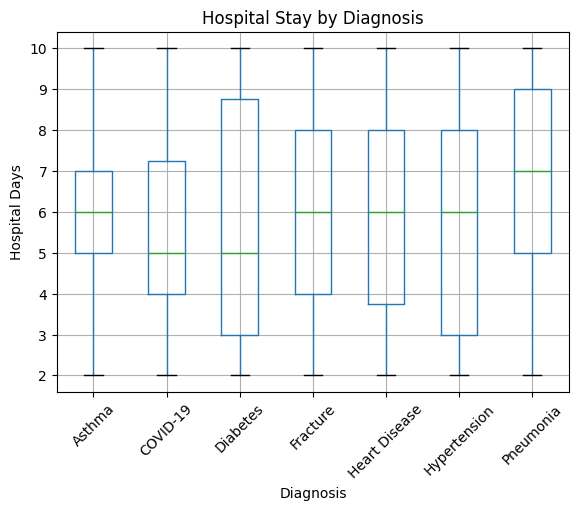

In [20]:
plt.figure()
df.boxplot(column='hospital_days', by='diagnosis')

plt.title("Hospital Stay by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Hospital Days")
plt.xticks(rotation=45)
plt.show()

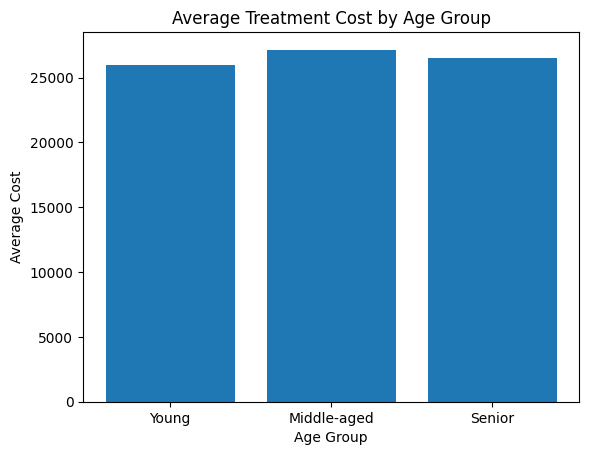

In [23]:
avg_cost = df.groupby('age_group')['treatment_cost'].mean()

plt.figure()
plt.bar(avg_cost.index.astype(str), avg_cost.values)

plt.title("Average Treatment Cost by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Cost")
plt.show()